# Validate `okx-highfrequency` 15m Conversion with OKX Web Klines

This notebook compares processed data from `target/hf_15m.csv` against BTC-USDT 15-minute kline data requested from OKX REST API (`/api/v5/market/history-candles`) for one UTC day.

Validation outputs include:
- timestamp alignment check
- key numeric error metrics
- side-by-side visualizations for price and volume


In [1]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.8f}".format

In [2]:
CSV_PATH = Path("target/hf_15m.csv")
INST_ID = "BTC-USDT"
BAR = "15m"
VALIDATION_DAY = "2025-10-02"  # UTC day with full 96 rows in the processed file

processed = pd.read_csv(CSV_PATH)
processed["DT"] = pd.to_datetime(processed["DT"], utc=True)

numeric_cols = ["PRICE", "SIZE", "BID", "OFR", "BIDSIZ", "OFRSIZ", "MIDQUOTE"]
processed[numeric_cols] = processed[numeric_cols].apply(pd.to_numeric, errors="coerce")

row_counts = processed.assign(day=processed["DT"].dt.date).groupby("day").size()
print(f"processed rows: {len(processed)}")
print(f"processed day range: {processed['DT'].min()} -> {processed['DT'].max()}")
print("\nrows per day (head):")
display(row_counts.head())

processed rows: 2975
processed day range: 2025-10-01 00:15:00+00:00 -> 2025-10-31 23:45:00+00:00

rows per day (head):


day
2025-10-01    95
2025-10-02    96
2025-10-03    96
2025-10-04    96
2025-10-05    96
dtype: int64

In [3]:
def fetch_okx_history_window(inst_id: str, day_utc: pd.Timestamp, bar: str = "15m") -> pd.DataFrame:
    """Fetch a small historical window around one UTC day from OKX history-candles."""
    if day_utc.tz is None:
        day_utc = day_utc.tz_localize("UTC")

    day_start = day_utc.floor("D")
    day_end = day_start + pd.Timedelta(days=1)

    # OKX docs: `after` returns records earlier than the provided ts.
    after_ms = int(day_end.timestamp() * 1000) + 1

    url = "https://www.okx.com/api/v5/market/history-candles"
    params = {
        "instId": inst_id,
        "bar": bar,
        "after": str(after_ms),
        "limit": "100",  # enough for 1 day (96 bars) plus boundary bars
    }

    resp = requests.get(url, params=params, timeout=20)
    resp.raise_for_status()
    payload = resp.json()

    if payload.get("code") != "0":
        raise RuntimeError(f"OKX API error: {payload}")

    cols = ["ts", "open", "high", "low", "close", "vol", "volCcy", "volCcyQuote", "confirm"]
    api = pd.DataFrame(payload.get("data", []), columns=cols)
    if api.empty:
        raise RuntimeError("No data returned from OKX history-candles endpoint.")

    for c in cols:
        api[c] = pd.to_numeric(api[c], errors="coerce")

    api["open_dt"] = pd.to_datetime(api["ts"].astype("int64"), unit="ms", utc=True)
    api = api.sort_values("open_dt").reset_index(drop=True)
    return api

In [4]:
validation_day = pd.Timestamp(VALIDATION_DAY, tz="UTC")
day_start = validation_day.floor("D")
day_end = day_start + pd.Timedelta(days=1)

processed_day = processed[processed["DT"].dt.date == validation_day.date()].copy()
processed_day = processed_day.sort_values("DT").reset_index(drop=True)

api_raw = fetch_okx_history_window(INST_ID, validation_day, BAR)

print(f"processed bars for {validation_day.date()}: {len(processed_day)}")
print(f"api rows in fetched window: {len(api_raw)}")
print(f"api window open_dt range: {api_raw['open_dt'].min()} -> {api_raw['open_dt'].max()}")

if len(processed_day) != 96:
    print("Warning: processed day is not 96 bars.")

processed bars for 2025-10-02: 96
api rows in fetched window: 100
api window open_dt range: 2025-10-01 23:15:00+00:00 -> 2025-10-03 00:00:00+00:00


In [5]:
# Compare two timestamp alignment options:
# 1) no shift: API open timestamp == processed DT
# 2) +15m shift: API open timestamp + 15m == processed DT (close-labeled bars)

api_no_shift = api_raw[(api_raw["open_dt"] >= day_start) & (api_raw["open_dt"] < day_end)].copy()
api_no_shift["DT"] = api_no_shift["open_dt"]
merged_no_shift = processed_day.merge(api_no_shift, on="DT", how="inner", suffixes=("_proc", "_api"))

api_plus_15m = api_raw[
    (api_raw["open_dt"] >= (day_start - pd.Timedelta(minutes=15)))
    & (api_raw["open_dt"] < (day_end - pd.Timedelta(minutes=15)))
].copy()
api_plus_15m["DT"] = api_plus_15m["open_dt"] + pd.Timedelta(minutes=15)
merged_plus_15m = processed_day.merge(api_plus_15m, on="DT", how="inner", suffixes=("_proc", "_api"))


def alignment_score(df: pd.DataFrame) -> float:
    return float((df["PRICE"] - df["close"]).abs().mean()) if len(df) else np.inf

score_no_shift = alignment_score(merged_no_shift)
score_plus_15m = alignment_score(merged_plus_15m)

print(f"no-shift price MAE: {score_no_shift:.8f} (rows={len(merged_no_shift)})")
print(f"+15m    price MAE: {score_plus_15m:.8f} (rows={len(merged_plus_15m)})")

aligned = merged_plus_15m if score_plus_15m <= score_no_shift else merged_no_shift
alignment_label = "api_open_plus_15m" if score_plus_15m <= score_no_shift else "api_open_no_shift"

print(f"selected alignment: {alignment_label}")

no-shift price MAE: 162.86562500 (rows=96)
+15m    price MAE: 0.16666667 (rows=96)
selected alignment: api_open_plus_15m


In [6]:
aligned = aligned.sort_values("DT").reset_index(drop=True)

aligned["price_diff"] = aligned["PRICE"] - aligned["close"]
aligned["abs_price_diff"] = aligned["price_diff"].abs()
aligned["size_diff"] = aligned["SIZE"] - aligned["vol"]
aligned["abs_size_diff"] = aligned["size_diff"].abs()

metrics = {
    "rows_compared": len(aligned),
    "price_mae": aligned["abs_price_diff"].mean(),
    "price_rmse": np.sqrt((aligned["price_diff"] ** 2).mean()),
    "price_max_abs_diff": aligned["abs_price_diff"].max(),
    "price_mean_diff": aligned["price_diff"].mean(),
    "price_corr": aligned["PRICE"].corr(aligned["close"]),
    "size_mae": aligned["abs_size_diff"].mean(),
    "size_max_abs_diff": aligned["abs_size_diff"].max(),
    "size_corr": aligned["SIZE"].corr(aligned["vol"]),
}

metrics_df = pd.DataFrame.from_dict(metrics, orient="index", columns=["value"])
display(metrics_df)

aligned[["DT", "PRICE", "close", "price_diff", "SIZE", "vol", "size_diff"]].head(10)

,value
rows_compared,96.00000000
price_mae,0.16666667
price_rmse,0.41658332
price_max_abs_diff,1.95000000
price_mean_diff,-0.00937500
price_corr,0.99999986
size_mae,0.00000042
size_max_abs_diff,0.00000130
size_corr,1.00000000


,DT,PRICE,close,price_diff,SIZE,vol,size_diff
0,2025-10-02 00:00:00+00:00,118607.65000000,118607.70000000,-0.05000000,90.19048473,90.19048521,-0.00000048
1,2025-10-02 00:15:00+00:00,119156.75000000,119156.80000000,-0.05000000,403.58796690,403.58796820,-0.00000130
2,2025-10-02 00:30:00+00:00,118936.85000000,118936.90000000,-0.05000000,141.83429660,141.83429735,-0.00000075
3,2025-10-02 00:45:00+00:00,118596.95000000,118598.00000000,-1.05000000,106.26366101,106.26366180,-0.00000079
4,2025-10-02 01:00:00+00:00,118440.25000000,118440.20000000,0.05000000,65.48281290,65.48281342,-0.00000052
5,2025-10-02 01:15:00+00:00,118700.25000000,118700.20000000,0.05000000,51.86333129,51.86333172,-0.00000043
6,2025-10-02 01:30:00+00:00,118500.25000000,118500.20000000,0.05000000,37.78971398,37.78971452,-0.00000054
7,2025-10-02 01:45:00+00:00,118731.75000000,118731.80000000,-0.05000000,267.68758665,267.68758711,-0.00000046
8,2025-10-02 02:00:00+00:00,118634.35000000,118634.40000000,-0.05000000,58.38412387,58.38412448,-0.00000061
9,2025-10-02 02:15:00+00:00,118699.95000000,118699.90000000,0.05000000,52.60727788,52.60727846,-0.00000058


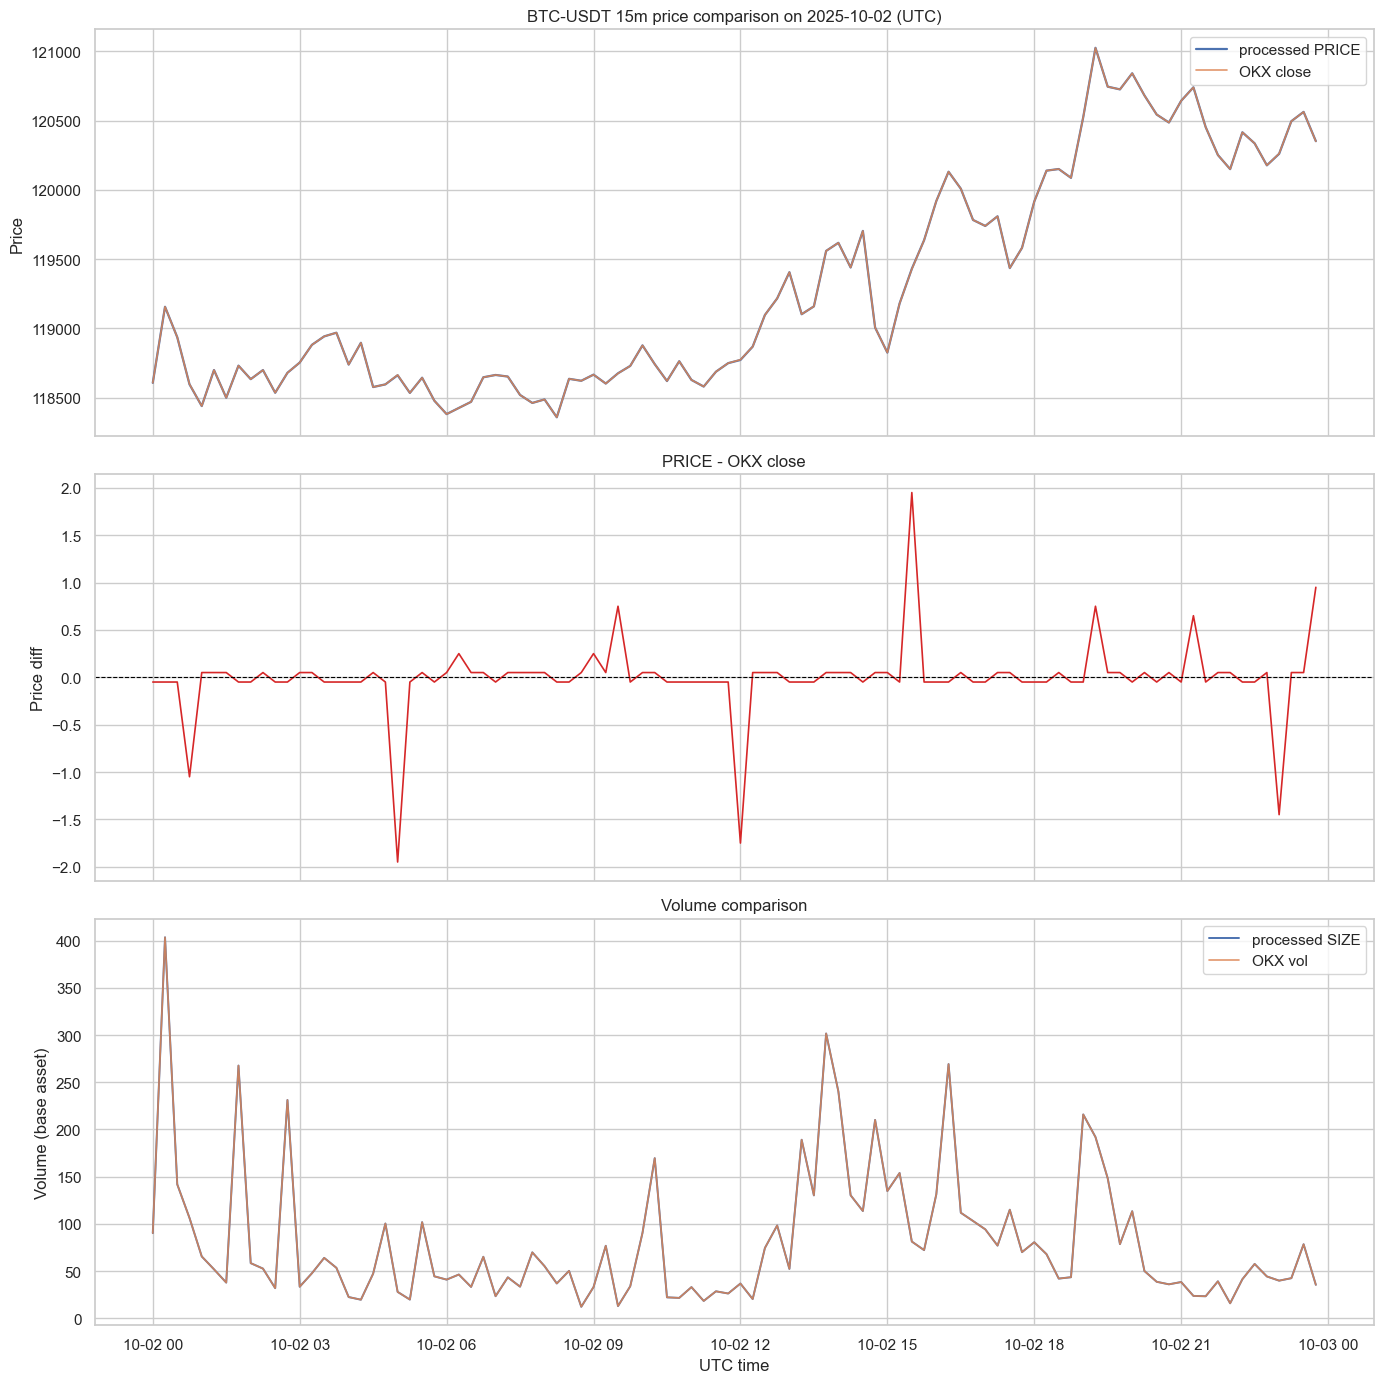

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

# Price path comparison
axes[0].plot(aligned["DT"], aligned["PRICE"], label="processed PRICE", linewidth=1.6)
axes[0].plot(aligned["DT"], aligned["close"], label="OKX close", linewidth=1.2, alpha=0.85)
axes[0].set_title(f"{INST_ID} 15m price comparison on {validation_day.date()} (UTC)")
axes[0].set_ylabel("Price")
axes[0].legend()

# Price difference
axes[1].plot(aligned["DT"], aligned["price_diff"], color="tab:red", linewidth=1.2)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("PRICE - OKX close")
axes[1].set_ylabel("Price diff")

# Volume comparison
axes[2].plot(aligned["DT"], aligned["SIZE"], label="processed SIZE", linewidth=1.4)
axes[2].plot(aligned["DT"], aligned["vol"], label="OKX vol", linewidth=1.2, alpha=0.85)
axes[2].set_title("Volume comparison")
axes[2].set_ylabel("Volume (base asset)")
axes[2].set_xlabel("UTC time")
axes[2].legend()

plt.tight_layout()
plt.show()

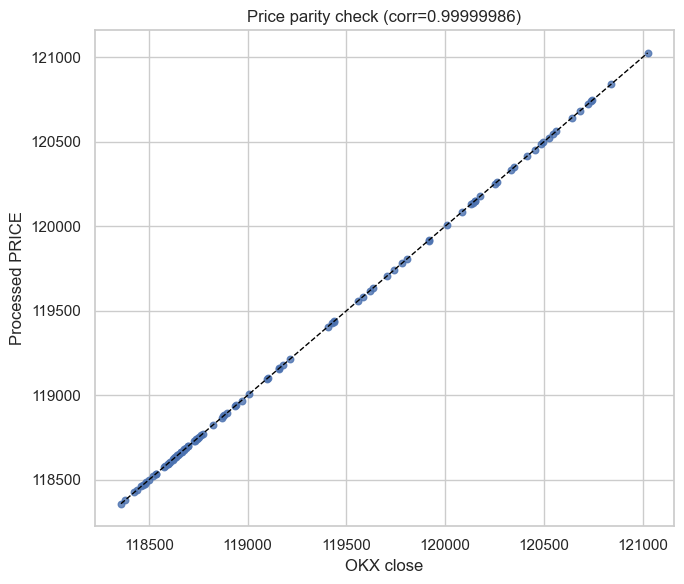

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(aligned["close"], aligned["PRICE"], s=22, alpha=0.8)
min_v = min(aligned["close"].min(), aligned["PRICE"].min())
max_v = max(aligned["close"].max(), aligned["PRICE"].max())
plt.plot([min_v, max_v], [min_v, max_v], color="black", linestyle="--", linewidth=1)
plt.xlabel("OKX close")
plt.ylabel("Processed PRICE")
plt.title(f"Price parity check (corr={metrics['price_corr']:.8f})")
plt.tight_layout()
plt.show()

## Interpretation Notes

- If `price_mae` is very small and `price_corr` is near 1, conversion quality is strong for close price.
- `size_mae` near zero indicates traded volume aggregation is consistent.
- A persistent small non-zero `price_diff` is usually a rounding precision effect (for example 0.05 tick rounding).
- If you want to validate another day, change `VALIDATION_DAY` and rerun all cells.
